# Import Libraries

In [1]:
import os
import random
import warnings
import logging
import pickle
import datetime
import time
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Logging
logging.basicConfig(level=logging.INFO)

# Embedding and NLP 
import fasttext
import fasttext.util
from nltk.tokenize import sent_tokenize, word_tokenize

# Keras and TensorFlow - model building
from keras.models import Sequential
from keras import Model, Input
from keras.layers import (
    Embedding, Dense, Dropout, LSTM, Bidirectional,
    TimeDistributed, InputLayer
)
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical, plot_model
from keras.optimizers import Adam
from keras.initializers import Constant

# Alternatively, from TensorFlow Keras (if mixed usage is needed)
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop

# Scikit-learn  + Keras compatibility
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    matthews_corrcoef, confusion_matrix,
    make_scorer, f1_score
)
from sklearn import metrics
from sklearn.utils import shuffle
from scikeras.wrappers import KerasClassifier

### Set Random Seeds to ensure reproducibility across runs by fixing all random generators.

In [2]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)


# Data Loading

In [3]:
df_train = pd.read_csv('data/train_zero_shot_preprocessed.csv')
df_dev = pd.read_csv('data/test_preprocessed.csv')

In [4]:
df_dev.head(2)

,id,language,mwe,previous,target,next,label,dataid,previous_cleaned,target_cleaned,next_cleaned
0,250,EN,bow tie,"With our new system, users can create the trad...",The Bow Tie Inlay System includes four separat...,"The Starter Kit with Frame, Bit and Bushing is...",1,dev.EN.144.2,new system users create traditional shapes als...,bow tie inlay system includes four separate sets,starter kit frame bit bushing base rest sets
1,436,EN,life vest,"If you're shopping for a child or children, yo...","They'll be more comfortable, and ultimately sa...",Here are a few of our top picks of kayaking li...,0,dev.EN.275.3,shopping child children wise purchase option s...,comfortable ultimately safer event emergency p...,top picks kayaking life vests kids


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   dataid            4489 non-null   object
 1   language          4489 non-null   object
 2   mwe               4489 non-null   object
 3   setting           4489 non-null   object
 4   previous          4489 non-null   object
 5   target            4489 non-null   object
 6   next              4489 non-null   object
 7   label             4489 non-null   int64 
 8   previous_cleaned  4488 non-null   object
 9   target_cleaned    4489 non-null   object
 10  next_cleaned      4489 non-null   object
dtypes: int64(1), object(10)
memory usage: 385.9+ KB


In [6]:
df_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 739 entries, 0 to 738
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                739 non-null    int64 
 1   language          739 non-null    object
 2   mwe               739 non-null    object
 3   previous          739 non-null    object
 4   target            739 non-null    object
 5   next              739 non-null    object
 6   label             739 non-null    int64 
 7   dataid            739 non-null    object
 8   previous_cleaned  739 non-null    object
 9   target_cleaned    739 non-null    object
 10  next_cleaned      738 non-null    object
dtypes: int64(2), object(9)
memory usage: 63.6+ KB


In [7]:
df_train = df_train.dropna()
df_dev = df_dev.dropna()

## Examines structure and content of datasets.

In [8]:
def concat_target_next_prev(df_original):
    # #Fill missing spaces and concatenate the three columns for further processing
    for df in [df_original]:
        df['previous_cleaned'] = df['previous_cleaned'].fillna("")
        df['next_cleaned'] = df['next_cleaned'].fillna("")
        df['combined_text'] = df['previous_cleaned'] + " " + df['target_cleaned'] + " " + df['next_cleaned']
    return df_original

In [9]:
df_dev = concat_target_next_prev(df_dev)
df_train = concat_target_next_prev(df_train)

Mean sequence length: 41.92223707664884
Median sequence length: 40.0
Max sequence length: 134


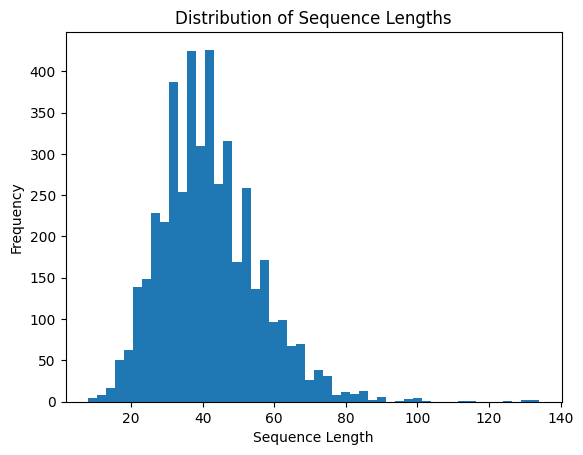

In [10]:
sequence_lengths = df_train['combined_text'].apply(lambda x: len(x.split())).values

print("Mean sequence length:", np.mean(sequence_lengths))
print("Median sequence length:", np.median(sequence_lengths))

max_seq = np.max(sequence_lengths)
print("Max sequence length:", max_seq)

plt.hist(sequence_lengths, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sequence Lengths")
plt.show()


In [11]:
print(df_dev['combined_text'])

0      new system users create traditional shapes als...
1      shopping child children wise purchase option s...
2      hurry cut nose patty whispered smothering seem...
3      agora estudo sugere procurar elos perdidos atr...
4      escreveu texto acusando ator coluna revista ho...
                             ...                        
734    create website bow tie business bow ties prima...
735    grant norris chain reaction cycles said fantas...
736    dois decidiram hospedar one nature hotels and ...
737    family friends mourning relatedfamous private ...
738    announcement released market close wednesday c...
Name: combined_text, Length: 738, dtype: object


#### Note: 
- with a max sequence length of 134 characters per sentence. It makes sense to set the parameter for 150.
- in terms of max nb words, keeping it 40K since the vocab size is 36679
    - for both, keeping a bit of air above to make sure everything is captured, yet not too much to avoid risk of unnecessarily increasing computational time

# Data Preparation
- keras tokenizer was depreciated so using tf keras text vectorizer
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization
- https://medium.com/analytics-vidhya/building-a-text-classification-model-using-bilstm-c0548ace26f2

## Text vectorization (Tokenization & Padding)

In [12]:
#Adjust text data text to np array
train_text = np.array(df_train['combined_text'])
dev_text = np.array(df_dev['combined_text'])

In [13]:
# Hyperparameters
MAX_NB_WORDS = 9000
MAX_SEQUENCE_LENGTH = int(max_seq+(0.1*max_seq)) # maximum sequence length)
print ("Max Seq Length:", MAX_SEQUENCE_LENGTH)

# Create the TextVectorization layer.
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_NB_WORDS,                # Limit on vocabulary size
    output_mode='int',                      # Output integer indices for tokens
    output_sequence_length=MAX_SEQUENCE_LENGTH  # Pad/truncate sequences to this length
)

# Adapt - build the vocab from training data
vectorize_layer.adapt(train_text)

#Examine vocab size
vocabulary = vectorize_layer.get_vocabulary()
print("Unique vocabulary size:", len(vocabulary)+1) # +1 is needed here because the first row is reserved by a padding token

# Hyperparameters, Update max nb words based on vocab size
MAX_NB_WORDS = len(vocabulary)+1      # maximum number of words to keep
print ("Max NB Words:", MAX_NB_WORDS)

# Covert the vocabulary list to a dictionary
word_index = {word: idx for idx, word in enumerate(vocabulary)}

Max Seq Length: 147
Unique vocabulary size: 9001
Max NB Words: 9001


## Data and Labels for Train, Val, Test

In [14]:
# Transform the texts into padded sequences
X_train_pad = vectorize_layer(train_text)
X_dev_pad = vectorize_layer(dev_text)

# Extract labels.
y_train = df_train['label'].values
y_dev = df_dev['label'].values

# Convert padded sequences and labels to NumPy
X_train_np = np.array(X_train_pad)  
y_train_np = np.array(y_train) 
X_dev_np = np.array(X_dev_pad)  
y_dev_np = np.array(y_dev) 

## Load fasttext Pretrained Embeddings
- Prepare the embedding matrix: https://medium.com/analytics-vidhya/building-a-text-classification-model-using-bilstm-c0548ace26f2

In [15]:
# Load embeddings_dict from the file
with open("fasttext_embeddings_en.pkl", "rb") as f:
    embeddings_dict = pickle.load(f)

print("FastText embeddings loaded successfully!")
print('Total %s word vectors loaded.' % len(embeddings_dict))

FastText embeddings loaded successfully!
Total 301779 word vectors loaded.


In [16]:
embedding_dim = 300  # Dimension of your fastText embeddings.
num_words = min(MAX_NB_WORDS, len(vocabulary))  #not needed
embedding_matrix = np.zeros((len(vocabulary) + 1, embedding_dim))

# The vectorizer's vocabulary is a list where each token's index is its position.
# (Often index 0 is reserved for padding.)
word_index
for word, i in word_index.items():
    embedding_vector = embeddings_dict.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Model Training with Grid Search
- https://machinelearningmastery.com/grid-search-hyperparameters-deep-learning-models-python-keras/
- https://machinelearningmastery.com/understand-the-dynamics-of-learning-rate-on-deep-learning-neural-networks/

In [17]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)

NameError: name 'TensorBoard' is not defined

## Defining stacks layers for the BiLSTM architecture

In [18]:
# Using default values here that will be replaces by Grid Search of Hyperparameters

def build_model(dropout_rate=0.3, lstm_units=64, optimizer='adam',
                embedding_dim=300, vocabulary_size=None, embedding_matrix=None):
    
    sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')
    
    embedding_layer = Embedding(
        input_dim=vocabulary_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
    
    embedded = embedding_layer(sequence_input)
    blstm = Bidirectional(LSTM(units=lstm_units, return_sequences=False))(embedded)
    dropout = Dropout(rate=dropout_rate)(blstm)
    dense = Dense(8 * lstm_units, activation='relu')(dropout)
    output = Dense(2, activation='softmax')(dense)

    model = Model(inputs=sequence_input, outputs=output)

    # specifically to add custom learning rate to the optimizers
    if isinstance(optimizer, str):
        model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    else:
        model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


## Compile the Model: Specifies the optimizer, loss function, and metrics.

In [19]:
# Using default values here that will be replaces by Grid Search of Hyperparameters

model = KerasClassifier(
    model=build_model,
    optimizer="adam",
    lstm_units=64,
    dropout_rate=0.3,
    epochs=5,
    batch_size=32,
    verbose=1,
    embedding_dim=300,
    vocabulary_size=len(vocabulary) + 1,
    embedding_matrix=embedding_matrix
)

In [20]:
param_grid = {
    "batch_size": [16, 32],
    "epochs": [16], 
    "model__optimizer": [Adam(learning_rate=1e-3), 
                         RMSprop(learning_rate=1e-3)],
    "model__lstm_units": [32, 64], 
    "model__dropout_rate": [0.2],
    "fit__validation_data": [(X_dev_np, y_dev_np)]
}

## Trains the model with Grid Search for Hyperparameter tuning 

In [21]:
start_time = time.time()
# Run the grid search
grid = GridSearchCV(estimator=model, 
                    param_grid=param_grid, 
                    scoring=make_scorer(f1_score, average='macro'),    
                    cv=3, 
                    verbose = 1, 
                    n_jobs=1)

grid_result = grid.fit(X_train_np,y_train_np)
end_time = time.time()

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Epoch 1/16
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5735 - loss: 0.6791 - val_accuracy: 0.5664 - val_loss: 0.7084
Epoch 2/16
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6905 - loss: 0.6067 - val_accuracy: 0.5827 - val_loss: 0.7127
Epoch 3/16
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7382 - loss: 0.5412 - val_accuracy: 0.5881 - val_loss: 0.7198
Epoch 4/16
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7631 - loss: 0.4964 - val_accuracy: 0.5881 - val_loss: 0.7144
Epoch 5/16
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7893 - loss: 0.4496 - val_accuracy: 0.5664 - val_loss: 0.7592
Epoch 6/16
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8206 - loss: 0.4086 - val_accuracy: 0.5474 - val_loss: 0.8532
Epoch 7/16
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8403 - loss: 0.3677 - val_accuracy: 0.5528 - val_loss: 0.9178
Epoch 8/16
187/187 ━━━━━━━━━━━━━━━━━━

In [22]:
elapsed_time = end_time - start_time
mins, secs = divmod(elapsed_time, 60)
print(f"Total Training Time: {int(mins)}m {int(secs)}s")

Total Training Time: 54m 38s


## Fetching Model with Best Parameters

In [23]:
best_model = grid_result.best_estimator_
best_model.model_.summary()

# Print best results
print("Best Parameters:", best_model)

best_model.model_.save("best_bilstm_model.h5")

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 147)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_24 (Embedding)        │ (None, 147, 300)       │     2,700,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_24                │ (None, 64)             │        85,248 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,007,508 (11.47 MB)

 Trainable params: 102,402 (400.01 KB)

 Non-trainable params: 2,700,300 (10.30 MB)

 Optimizer params: 204,806 (800.03 KB)

Best Parameters: KerasClassifier(
	model=<function build_model at 0x2a63637e0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=adam
	loss=None
	metrics=None
	batch_size=16
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=16
	lstm_units=64
	dropout_rate=0.3
	embedding_dim=300
	vocabulary_size=9001
	embedding_matrix=[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.14996    -0.18911999 -0.31939    ...  0.0038557   0.13015001
  -0.0495    ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.14184    -0.40414    -0.37643999 ...  0.13982999 -0.014742
   0.20376   ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
	class_weight=None
	fit__validation_data=(array([[   4,  158,  540, ...,    0,    0,    0],
       [2020, 1013,  408, ...,    0,    0,    0],


## Validation and Trainign Loss over Epochs

In [24]:
history = best_model.model_.history.history
print("Final val_loss:", history['val_loss'][-1])

Final val_loss: 2.3027050495147705


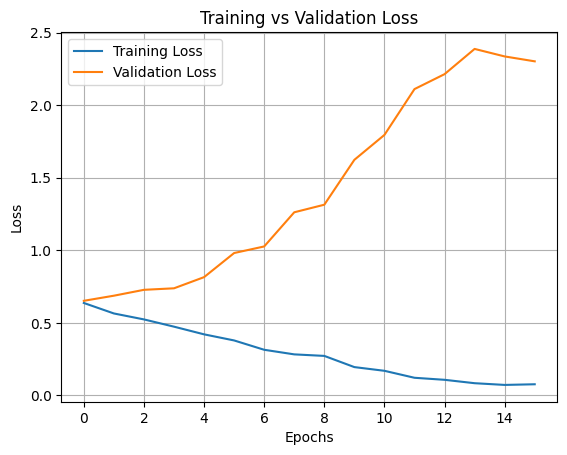

In [25]:
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## Plot of Loss per Fold of Grid Search

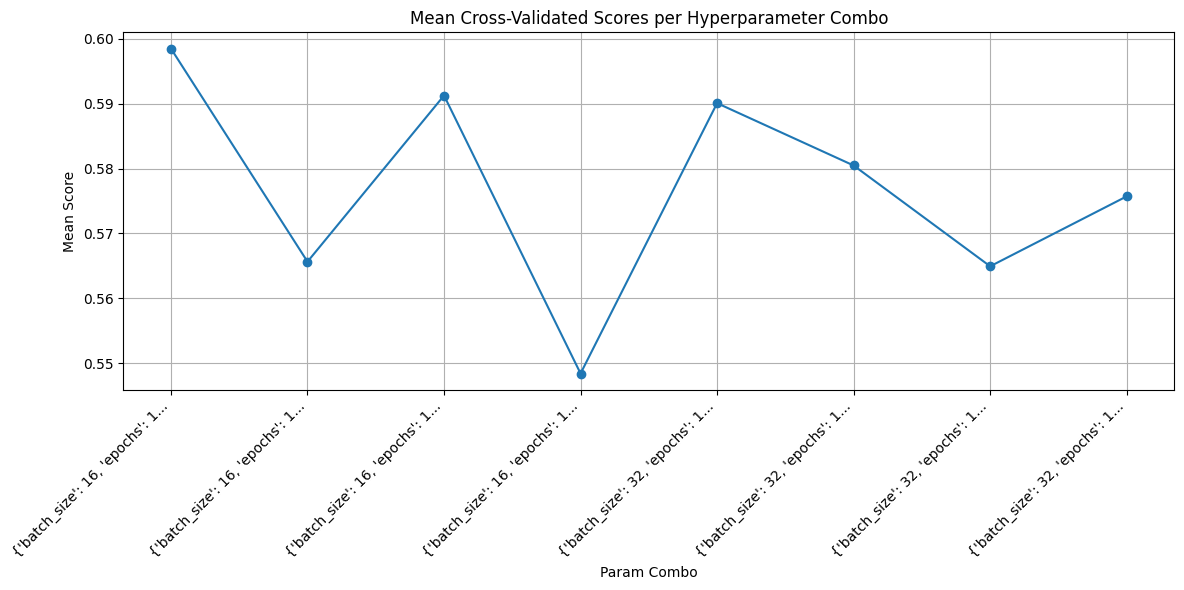

In [30]:
# Accessing the history inside each model inside GridSearchCV
results = grid_result.cv_results_
mean_scores = results["mean_test_score"]
params = results["params"]

plt.figure(figsize=(12, 6))
plt.plot(range(len(mean_scores)), mean_scores, marker='o')
short_labels = [str(p)[:30] + "..." for p in params]  # trim to 30 characters
plt.xticks(ticks=range(len(params)), labels=short_labels, rotation=45, ha='right')
plt.title("Mean Cross-Validated Scores per Hyperparameter Combo")
plt.xlabel("Param Combo")
plt.ylabel("Mean Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluation with Dev Set

In [31]:
def plot_confusion_matrices(y_true, y_pred, labels=None, label_names=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    if labels is None:
        labels = np.unique(np.concatenate((y_true, y_pred)))

    if label_names is None:
        label_names = labels  # fallback to numbers

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[0],
                xticklabels=label_names, yticklabels=label_names)
    axs[0].set_title("Confusion Matrix (Counts)")
    axs[0].set_xlabel("Predicted")
    axs[0].set_ylabel("Actual")

    sns.heatmap(cm_norm * 100, annot=True, fmt='.1f', cmap='Greens', ax=axs[1],
                xticklabels=label_names, yticklabels=label_names)
    axs[1].set_title("Confusion Matrix (Row %)")
    axs[1].set_xlabel("Predicted")
    axs[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

## Classification Metrics

In [32]:
predicted_classes = best_model.predict(X_dev_pad)
print(metrics.classification_report(y_dev, predicted_classes, zero_division=1))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.53      0.73      0.61       335
           1       0.67      0.46      0.54       403

    accuracy                           0.58       738
   macro avg       0.60      0.59      0.58       738
weighted avg       0.60      0.58      0.57       738



## Confusion Matrices

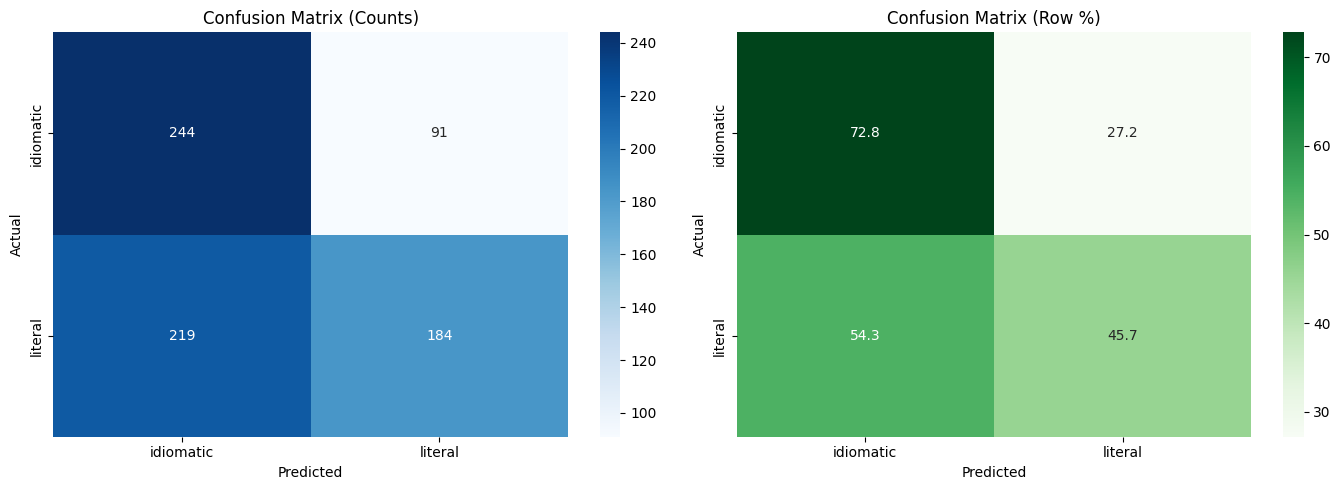

In [33]:
plot_confusion_matrices(y_dev, predicted_classes, labels=[0,1],
                       label_names=['idiomatic', 'literal'])